In [701]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

goalscorers=pd.read_csv("goalscorers.csv")
results=pd.read_csv("results.csv")
shootouts = pd.read_csv("shootouts.csv")


In [702]:
shootouts.drop(columns=['first_shooter'], inplace=True)
shootouts

,date,home_team,away_team,winner
0,1967-08-22,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand
...,...,...,...,...
678,2026-06-06,Raetia,Rouet-Provence,Rouet-Provence
679,2026-06-29,Germany,Paraguay,Paraguay
680,2026-06-29,Netherlands,Morocco,Morocco
681,2026-07-03,Australia,Egypt,Egypt


In [703]:
goalscorers.isna().sum()

date           0
home_team      0
away_team      0
team           0
scorer        44
minute       254
own_goal       0
penalty        0
dtype: int64

In [704]:
goalscorers.duplicated().sum()

np.int64(79)

In [705]:
goalscorers.drop_duplicates(inplace=True)
goalscorers.dropna(inplace=True)
results.drop_duplicates(inplace=True)
results.dropna(inplace=True)
shootouts.drop_duplicates(inplace=True)
shootouts.dropna(inplace=True)

In [706]:
df=pd.merge(goalscorers,results, on=["date","home_team","away_team"])
df

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,6.0,1.0,Copa América,Buenos Aires,Argentina,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47634,2026-07-14,France,Spain,Spain,Mikel Oyarzabal,22.0,False,True,0.0,2.0,FIFA World Cup,Arlington,United States,True
47635,2026-07-14,France,Spain,Spain,Pedro Porro,58.0,False,False,0.0,2.0,FIFA World Cup,Arlington,United States,True
47636,2026-07-15,England,Argentina,England,Anthony Gordon,55.0,False,False,1.0,2.0,FIFA World Cup,Atlanta,United States,True
47637,2026-07-15,England,Argentina,Argentina,Enzo Fernández,85.0,False,False,1.0,2.0,FIFA World Cup,Atlanta,United States,True


scorer
Cristiano Ronaldo      124
Harry Kane              75
Lionel Messi            71
Robert Lewandowski      68
Romelu Lukaku           67
Edin Džeko              58
Erling Haaland          53
Kylian Mbappé           53
Aleksandar Mitrović     52
Luis Suárez             51
dtype: int64


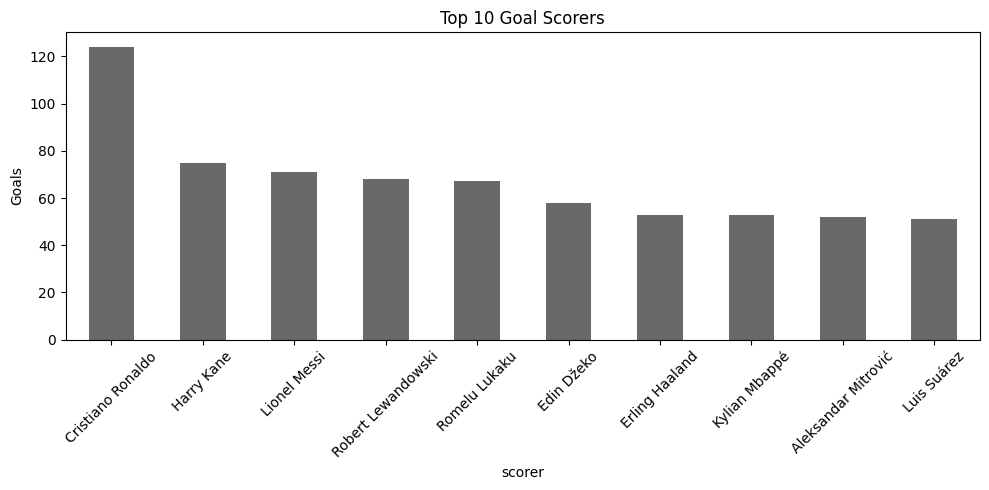

In [707]:
top_10_scorers = (
    df[df["own_goal"] == False]
    .groupby("scorer")
    .size()
    .sort_values(ascending=False)
)
print(top_10_scorers.head(10))

plt.figure(figsize=(10,5))
top_10_scorers.head(10).plot(kind="bar", color="dimgray")
plt.title("Top 10 Goal Scorers")
plt.ylabel("Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

England        2395.0
Germany        2331.0
Brazil         2315.0
Sweden         2178.0
Argentina      2047.0
Hungary        2011.0
Netherlands    1852.0
South Korea    1794.0
Mexico         1777.0
France         1731.0
dtype: float64


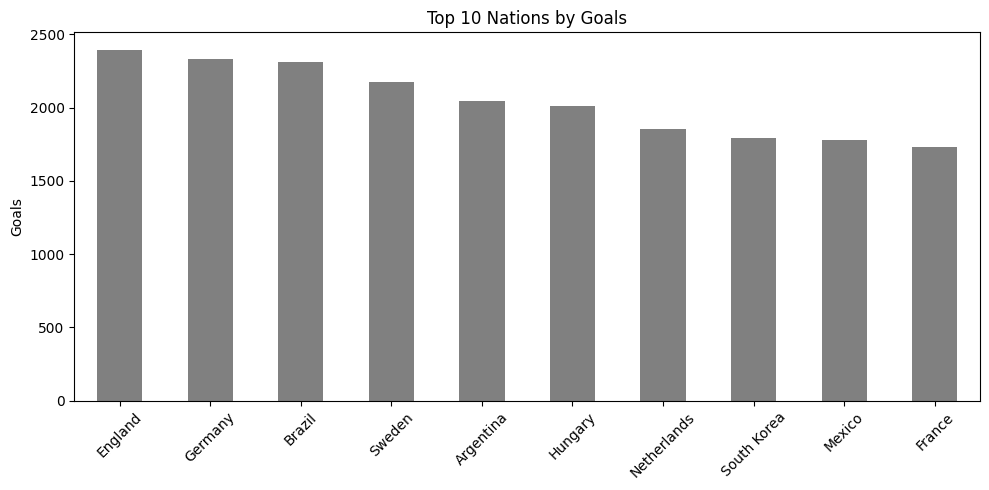

In [708]:
home = results.groupby("home_team")["home_score"].sum()
away = results.groupby("away_team")["away_score"].sum()

top_10_nations = (
    pd.concat([home, away])
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

print(top_10_nations.head(10))

plt.figure(figsize=(10,5))
top_10_nations.head(10).plot(kind="bar", color="gray")
plt.title("Top 10 Nations by Goals")
plt.ylabel("Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [709]:
conditions=[(results["home_score"]>results["away_score"]),
            (results["home_score"]<results["away_score"]),
            (results["home_score"]==results["away_score"])]

results["home_points"]=np.select(conditions,[3,0,1])
results["away_points"]=np.select(conditions,[0,3,1])
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_points,away_points
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,3,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,3,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1,1
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3,0
...,...,...,...,...,...,...,...,...,...,...,...
49513,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,Inglewood,United States,True,3,0
49514,2026-07-11,Norway,England,1.0,2.0,FIFA World Cup,Miami Gardens,United States,True,0,3
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True,3,0
49516,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,Arlington,United States,True,0,3


Brazil         2.107143
Jersey         2.038298
Spain          2.005063
England        1.958979
Germany        1.948792
Iran           1.941463
Guernsey       1.916667
Argentina      1.908922
Italy          1.874580
South Korea    1.850495
dtype: float64


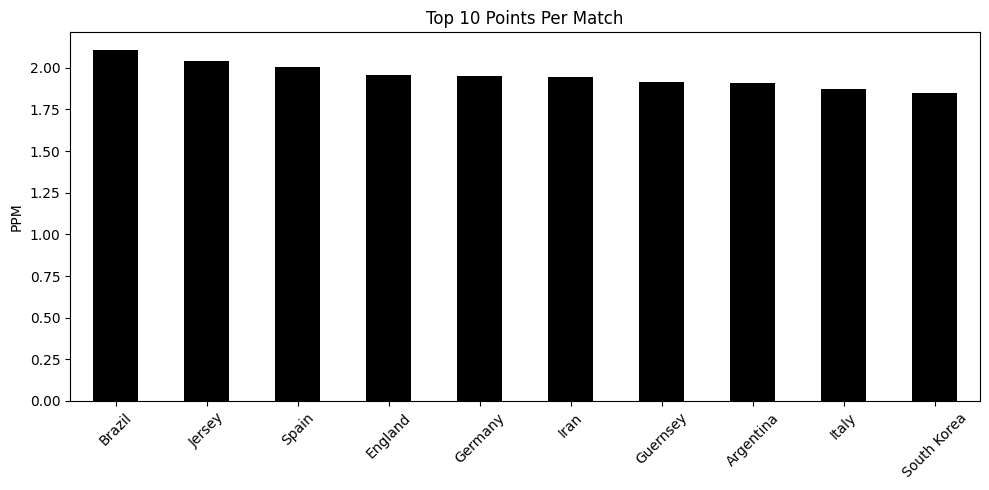

In [710]:
home_points=results.groupby("home_team")["home_points"].sum()
away_points=results.groupby("away_team")["away_points"].sum()

home_matches=results.groupby("home_team").size()
away_matches=results.groupby("away_team").size()

matches=pd.concat([away_matches,home_matches]).groupby(level=0).sum()

matches=matches[matches>100]

total_points=pd.concat([away_points,home_points]).groupby(level=0).sum()
ppm = (total_points / matches).sort_values(ascending=False)

print(ppm.head(10))

plt.figure(figsize=(10,5))
ppm.head(10).plot(kind="bar", color="black")
plt.title("Top 10 Points Per Match")
plt.ylabel("PPM")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Jersey              2.744681
Tahiti              2.714876
New Caledonia       2.633962
Guernsey            2.566667
Fiji                2.268657
Germany             2.252174
England             2.183227
Brazil              2.175752
Papua New Guinea    2.167742
Solomon Islands     2.158879
dtype: float64


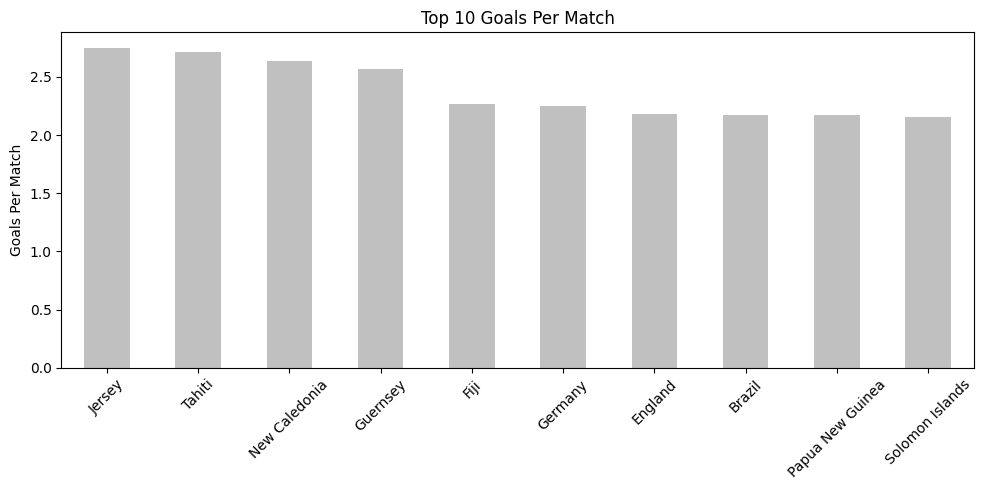

In [711]:
gpm = (top_10_nations / matches).sort_values(ascending=False)

print(gpm.head(10))

plt.figure(figsize=(10,5))
gpm.head(10).plot(kind="bar", color="silver")
plt.title("Top 10 Goals Per Match")
plt.ylabel("Goals Per Match")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [712]:
df["date"] = pd.to_datetime(df["date"])
df["decade"] = (df["date"].dt.year // 10) * 10

results["decade"] = pd.to_datetime(results["date"])
results["decade"] = (results["decade"].dt.year // 10) * 10

shootouts = shootouts.merge(
    results[["date", "home_team", "away_team", "tournament"]],
    on=["date", "home_team", "away_team"],
    how="left"
)

shootouts["date"] = pd.to_datetime(shootouts["date"])
shootouts["decade"] = (shootouts["date"].dt.year // 10) * 10
shootouts

,date,home_team,away_team,winner,tournament,decade
0,1967-08-22,India,Taiwan,Taiwan,Merdeka Tournament,1960
1,1971-11-14,South Korea,Vietnam Republic,South Korea,King's Cup,1970
2,1972-05-07,South Korea,Iraq,Iraq,AFC Asian Cup,1970
3,1972-05-17,Thailand,South Korea,South Korea,AFC Asian Cup,1970
4,1972-05-19,Thailand,Cambodia,Thailand,AFC Asian Cup,1970
...,...,...,...,...,...,...
678,2026-06-06,Raetia,Rouet-Provence,Rouet-Provence,CONIFA European Football Cup,2020
679,2026-06-29,Germany,Paraguay,Paraguay,FIFA World Cup,2020
680,2026-06-29,Netherlands,Morocco,Morocco,FIFA World Cup,2020
681,2026-07-03,Australia,Egypt,Egypt,FIFA World Cup,2020


decade
2010    153
2000    144
1990    126
2020    124
1980     97
1970     38
1960      1
dtype: int64


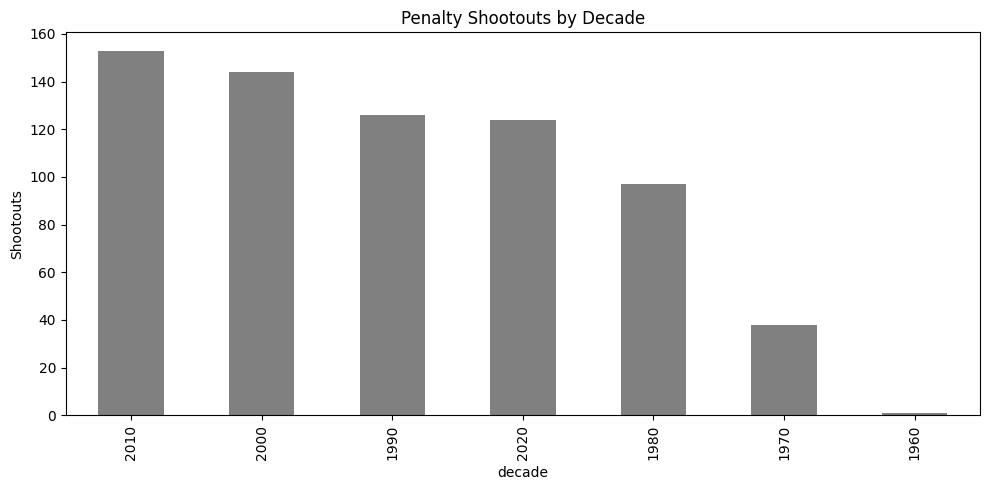

tournament
Friendly                                79
COSAFA Cup                              63
African Cup of Nations                  47
FIFA World Cup                          39
Copa América                            33
African Cup of Nations qualification    28
AFC Asian Cup                           27
UEFA Euro                               25
FIFA World Cup qualification            21
Gold Cup                                18
dtype: int64


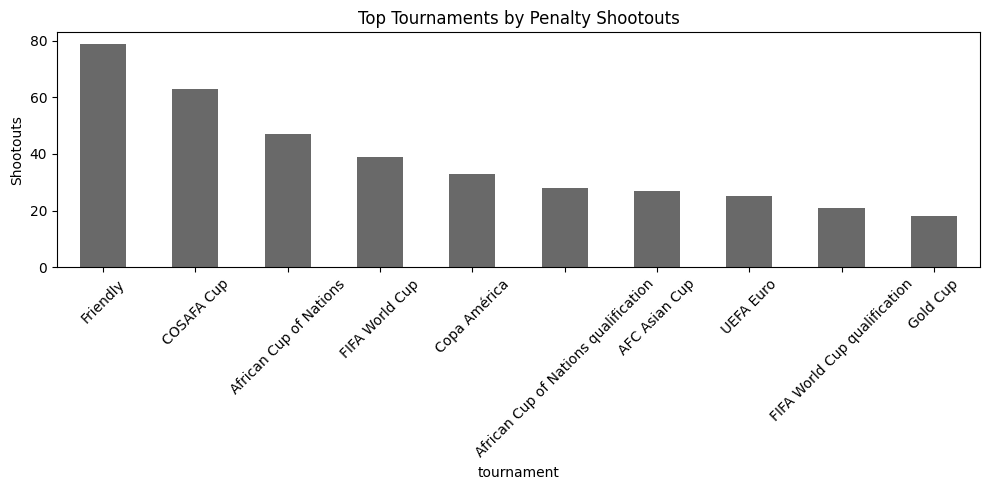

In [713]:
shootout_decades = shootouts.groupby("decade").size().sort_values(ascending=False)

print(shootout_decades)

plt.figure(figsize=(10,5))
shootout_decades.plot(kind="bar", color="gray")
plt.title("Penalty Shootouts by Decade")
plt.ylabel("Shootouts")
plt.tight_layout()
plt.show()

shootout_tournaments = (
    shootouts.groupby("tournament")
    .size()
    .sort_values(ascending=False)
)

print(shootout_tournaments.head(10))

plt.figure(figsize=(10,5))
shootout_tournaments.head(10).plot(kind="bar", color="dimgray")
plt.title("Top Tournaments by Penalty Shootouts")
plt.ylabel("Shootouts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [714]:
shootouts.groupby("tournament").size().sort_values(ascending=False).head(10)

tournament
Friendly                                79
COSAFA Cup                              63
African Cup of Nations                  47
FIFA World Cup                          39
Copa América                            33
African Cup of Nations qualification    28
AFC Asian Cup                           27
UEFA Euro                               25
FIFA World Cup qualification            21
Gold Cup                                18
dtype: int64

decade
2010    788
2020    777
2000    632
1990    420
1980    221
1970    187
1960    101
1950     67
1930     26
1940     20
dtype: int64


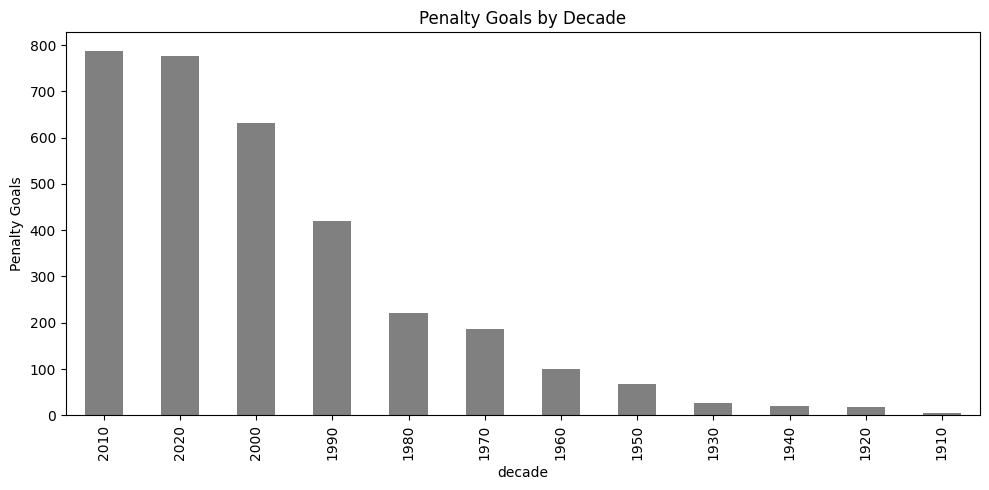

tournament
FIFA World Cup qualification    1621
UEFA Euro qualification          554
FIFA World Cup                   229
Copa América                     167
UEFA Nations League              164
African Cup of Nations           155
Gold Cup                         105
AFC Asian Cup                     92
UEFA Euro                         69
Confederations Cup                31
dtype: int64


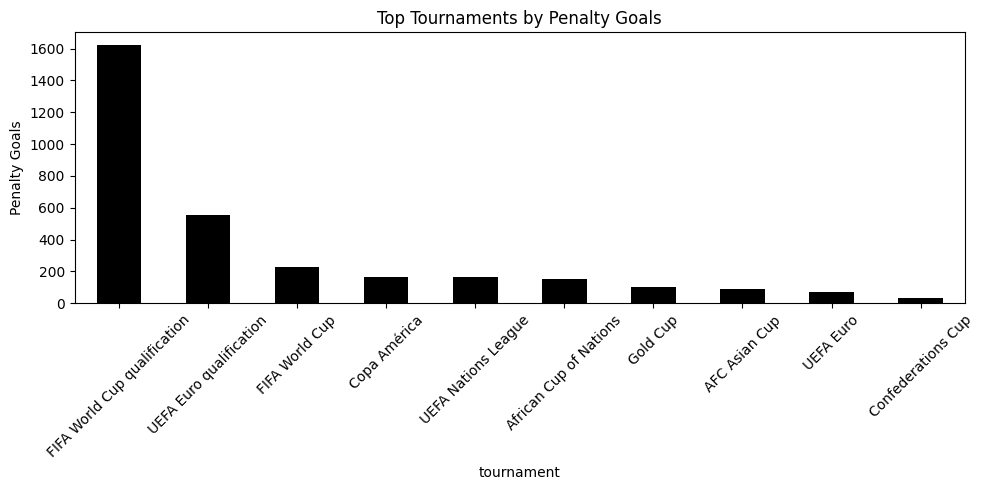

In [715]:
decade_penalties=df[df['penalty']==True].groupby('decade').size().sort_values(ascending=False)
print(decade_penalties.head(10))

plt.figure(figsize=(10,5))
decade_penalties.plot(kind="bar", color="gray")
plt.title("Penalty Goals by Decade")
plt.ylabel("Penalty Goals")
plt.tight_layout()
plt.show()

tournament_penalties = df[df['penalty']==True].groupby('tournament').size().sort_values(ascending=False)
print(tournament_penalties.head(10))

plt.figure(figsize=(10,5))
tournament_penalties.head(10).plot(kind="bar", color="black")
plt.title("Top Tournaments by Penalty Goals")
plt.ylabel("Penalty Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [716]:
conditions=[df["away_score"]>df["home_score"],df["away_score"]<df["home_score"]]
df["winner"]=np.select(conditions,[df["away_team"],df["home_team"]],default="draw")
df

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,home_score,away_score,tournament,city,country,neutral,decade,winner
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1910,Uruguay
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1910,Uruguay
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1910,Uruguay
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,0.0,4.0,Copa América,Buenos Aires,Argentina,True,1910,Uruguay
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,6.0,1.0,Copa América,Buenos Aires,Argentina,False,1910,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47634,2026-07-14,France,Spain,Spain,Mikel Oyarzabal,22.0,False,True,0.0,2.0,FIFA World Cup,Arlington,United States,True,2020,Spain
47635,2026-07-14,France,Spain,Spain,Pedro Porro,58.0,False,False,0.0,2.0,FIFA World Cup,Arlington,United States,True,2020,Spain
47636,2026-07-15,England,Argentina,England,Anthony Gordon,55.0,False,False,1.0,2.0,FIFA World Cup,Atlanta,United States,True,2020,Argentina
47637,2026-07-15,England,Argentina,Argentina,Enzo Fernández,85.0,False,False,1.0,2.0,FIFA World Cup,Atlanta,United States,True,2020,Argentina


team
Brazil                 57
Switzerland            54
Uruguay                52
Sweden                 51
Republic of Ireland    50
Denmark                49
Spain                  49
Paraguay               48
Belgium                48
Poland                 47
dtype: int64


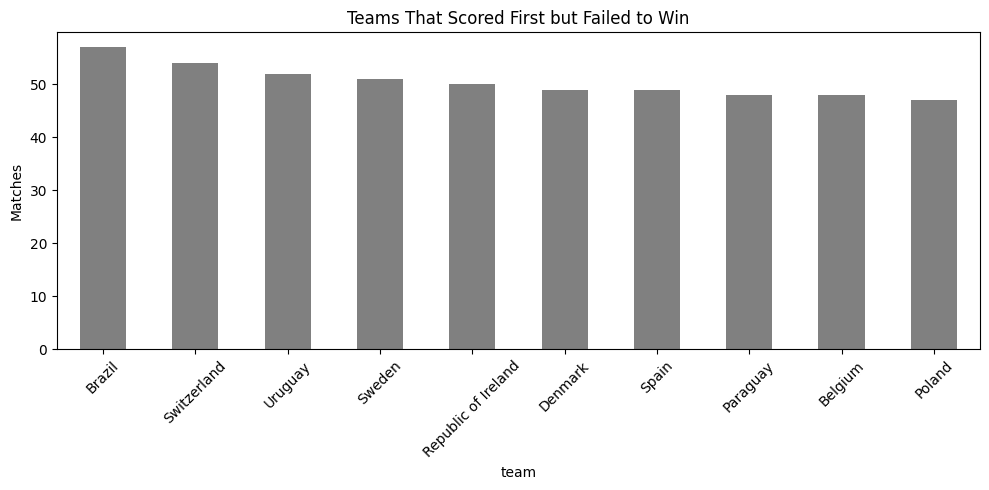

In [721]:
first_goals = df.loc[df.groupby(["date","home_team","away_team"])["minute"].idxmin()]
failed_wins=first_goals[first_goals["team"]!=first_goals["winner"]].groupby("team").size().sort_values(ascending=False)
print(failed_wins.head(10))

plt.figure(figsize=(10,5))
failed_wins.head(10).plot(kind="bar", color="gray")
plt.title("Teams That Scored First but Failed to Win")
plt.ylabel("Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

decade
1870    4.538462
1880    5.581818
1890    5.152542
1900    4.159420
1910    4.218182
1920    3.884477
1930    4.318814
1940    4.344538
1950    4.004240
1960    3.478963
1970    2.974837
1980    2.526766
1990    2.778946
2000    2.801973
2010    2.738429
2020    2.716450
dtype: float64


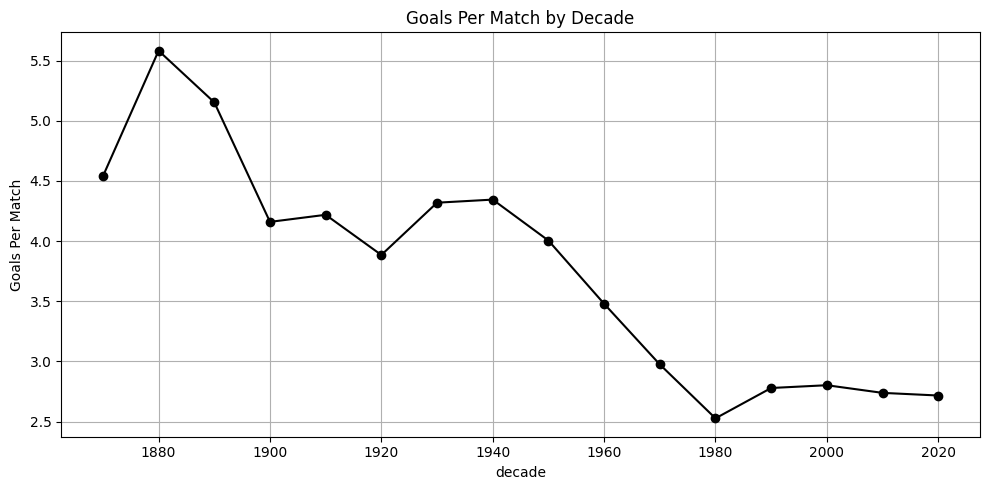

In [722]:
results["total_goals"] = results["home_score"] + results["away_score"]
matches= results.groupby('decade').size()
gpm_decades=results.groupby('decade')["total_goals"].sum()/ matches
print(gpm_decades)

plt.figure(figsize=(10,5))
gpm_decades.plot(marker="o", color="black")
plt.title("Goals Per Match by Decade")
plt.ylabel("Goals Per Match")
plt.grid(True)
plt.tight_layout()
plt.show()

decade
1870    15.384615
1880     9.090909
1890    15.254237
1900    17.391304
1910    16.060606
1920    17.930205
1930    15.940686
1940    15.366146
1950    18.352514
1960    19.623023
1970    21.824341
1980    26.129353
1990    24.294355
2000    23.444223
2010    23.265556
2020    23.078176
dtype: float64


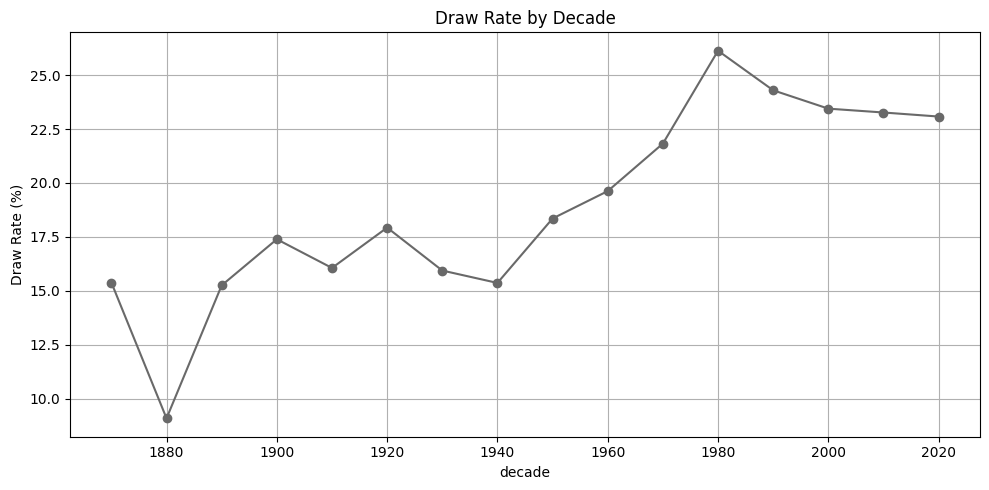

In [723]:
conditions=[results["away_score"]>results["home_score"],results["away_score"]<results["home_score"]]
results["winner"]=np.select(conditions,[results["away_team"],results["home_team"]],default="draw")
draw_rates=(results[results["winner"]=="draw"].groupby('decade').size()/matches)*100
print(draw_rates)

plt.figure(figsize=(10,5))
draw_rates.plot(marker="o", color="dimgray")
plt.title("Draw Rate by Decade")
plt.ylabel("Draw Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

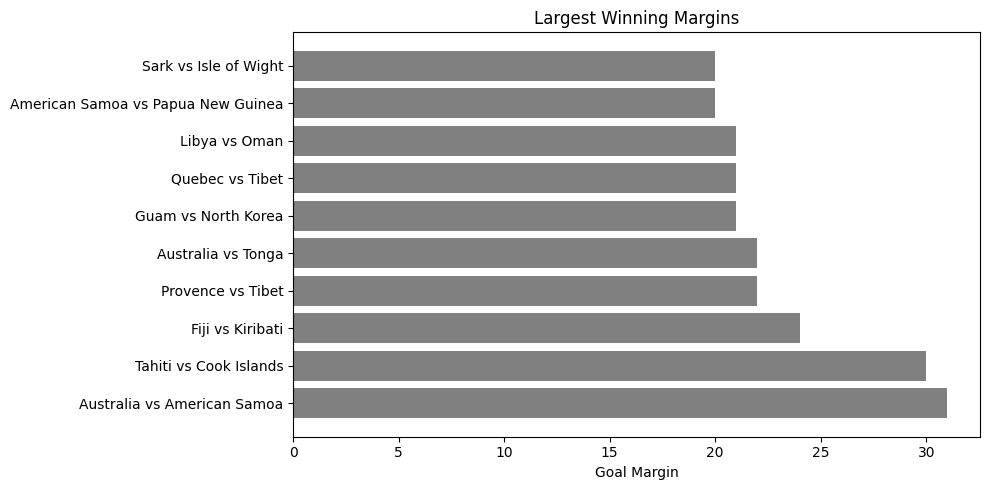

In [726]:
results["goal_margin"]=abs(results["away_score"]-results["home_score"])
goal_margin_decade=results.groupby("decade")["goal_margin"].sum()/matches

largest_wins = results.sort_values(
    "goal_margin",
    ascending=False
).head(10)

largest_wins["match"] = (
    largest_wins["home_team"]
    + " vs "
    + largest_wins["away_team"]
)

plt.figure(figsize=(10,5))
plt.barh(largest_wins["match"], largest_wins["goal_margin"], color="gray")
plt.title("Largest Winning Margins")
plt.xlabel("Goal Margin")
plt.tight_layout()
plt.show()


In [ ]:
print(goal_margin_decade)

plt.figure(figsize=(10,5))
goal_margin_decade.plot(marker="o", color="gray")
plt.title("Average Goal Margin by Decade")
plt.ylabel("Goal Margin")
plt.grid(True)
plt.tight_layout()
plt.show()